# Project Title: Real-Time Face Segmentation for Movie Cast Identification

***The python version is used in this project***

In [1]:
!python -V

Python 3.10.5


***The packages are used in the python environment***   
    - (The packages are listed in the requirements.txt file in the working directory)

In [2]:
pip list

Package                Version
---------------------- ------------
absl-py                2.4.0
albucore               0.0.24
albumentations         2.0.8
annotated-types        0.7.0
asttokens              3.0.1
astunparse             1.6.3
certifi                2026.2.25
charset-normalizer     3.4.7
colorama               0.4.6
comm                   0.2.3
contourpy              1.3.2
cycler                 0.12.1
debugpy                1.8.20
decorator              5.2.1
exceptiongroup         1.3.1
executing              2.2.1
flatbuffers            25.12.19
fonttools              4.62.1
gast                   0.7.0
google-pasta           0.2.0
grpcio                 1.80.0
h5py                   3.14.0
idna                   3.11
ipykernel              7.2.0
ipython                8.39.0
jedi                   0.19.2
joblib                 1.5.3
jupyter_client         8.8.0
jupyter_core           5.9.1
keras                  3.12.1
kiwisolver             1.5.0
libclang           

In [4]:
import os
import cv2
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import albumentations as A

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## STEP 1: The understanding about the given datasets

In [6]:
# data = np.load("Part 1- Train data - images.npy", mmap_mode='r')

data = np.load("Part 1- Train data - images.npy", allow_pickle=True)

### Try see the dataset

In [5]:
print(type(data))
print(len(data))

print(type(data[0]))
print(np.shape(data[0]))

<class 'numpy.ndarray'>
409
<class 'numpy.ndarray'>
(2,)


### Actually the dataset is,
    
    My interpretation is,.
        I comfirmed that 409 datasets are available
        Each sample is
            data[i] = (image, mask_list)

        where,
            image = it is actual image
            mask = Not a mask image, but something like a list of two elements

### Try to see the data in different way

In [6]:
img, mask = data[0]

print("Mask type:", type(mask))
print("Mask length:", len(mask))

print("Mask[0] type:", type(mask[0]))
print("Mask[1] type:", type(mask[1]))

Mask type: <class 'list'>
Mask length: 2
Mask[0] type: <class 'dict'>
Mask[1] type: <class 'dict'>


### Try to see the dataset in some other way

In [7]:
print(mask[0])

{'label': ['Face'], 'notes': '', 'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063}, {'x': 0.1723076923076923, 'y': 0.45345345345345345}], 'imageWidth': 650, 'imageHeight': 333}


## Finally understanding about the data

    From the output, the data is 
        mask = [dict, dict]
    
    That means
        data[i] = (image, [Annotation 1, Annotation 2])

    So, I understood that one image has one image and two faces(annotations)

In [ ]:
pprint.pprint(mask[0])

{'imageHeight': 333,
 'imageWidth': 650,
 'label': ['Face'],
 'notes': '',
 'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063},
            {'x': 0.1723076923076923, 'y': 0.45345345345345345}]}


### The final understanding of the data

    It is not just a numerical array vaues.

    I came to know that image is a list contains elements that are not consistent in shape or channels. The structure of the data is much deeper than I expected

    I think that some of the images are still different internally.

    It is like mix of grayscale/RGB/alpha channel image

    For this to find all, I need to run the following code

In [3]:
for i, (img, _) in enumerate(data):
    cv2.imwrite(f"image_{i}.jpg", img)

    I came to know from the above codes, some images are RGBA (4 Channels) and others are RGB (3 channels)

    Why, RGBA is like Red, Green, Blue, Alpha (transparency)

    But the deep learning project is expecting RGB(Red, Green, Blue).

    So we must remove the alpha channel safely.

### To create the final mask from all annotations

In [ ]:
def create_combined_mask(annotation_list, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in annotation_list:

        if 'points' in ann:
            pts = ann['points']

            # convert normalized one to pixel coordinates
            pts = np.array([
                [int(p['x'] * w), int(p['y'] * h)]
                for p in pts
            ], dtype=np.int32)

            # It is very important, check if only 2 points (bounding box case)
            if len(pts) == 2:
                x1, y1 = pts[0]
                x2, y2 = pts[1]
                cv2.rectangle(mask, (x1, y1), (x2, y2), 1, -1)

            else:
                cv2.fillPoly(mask, [pts], 1)

    return mask

### Building the datasets

In [ ]:
images = []
masks = []

for item in data:
    img, annotations = item

    # --- Fix the image channels ---
    if len(img.shape) == 2:  # grayscale
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    elif img.shape[2] == 4:  # RGBA → RGB (Remove Alpha Channels)
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)

    else:  # It is already 3 channels to save directly
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Create the mask ---
    mask = create_combined_mask(annotations, img.shape)

    # --- Resize all to standard size ---
    img = cv2.resize(img, (256,256))
    mask = cv2.resize(mask, (256,256))

    images.append(img)
    masks.append(mask)

# --- FINAL CONVERSION ---
images = np.array(images, dtype=np.float32) / 255.0
masks = np.expand_dims(np.array(masks, dtype=np.float32), axis=-1)

'\nimages = []\nmasks = []\n\nfor item in data:\n    img, annotations = item\n\n    # --- FIX IMAGE CHANNELS ---\n    if len(img.shape) == 2:  # grayscale\n        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)\n\n    elif img.shape[2] == 4:  # RGBA → RGB (REMOVE ALPHA)\n        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)\n\n    else:  # already 3 channels\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    # --- CREATE MASK ---\n    mask = create_combined_mask(annotations, img.shape)\n\n    # --- RESIZE ---\n    img = cv2.resize(img, (256,256))\n    mask = cv2.resize(mask, (256,256))\n\n    images.append(img)\n    masks.append(mask)\n\n# --- FINAL CONVERSION ---\nimages = np.array(images, dtype=np.float32) / 255.0\nmasks = np.expand_dims(np.array(masks, dtype=np.float32), axis=-1)\n'

    It fixed that

        - Removal of alpha channel
        - Convert Grayscale to RGB
        -  Standardized to (256, 256, 3)

    I verified with shape attribute as follows.

In [12]:
print(images.shape)
print(masks.shape)

(409, 256, 256, 3)
(409, 256, 256, 1)


### To visualize an image from the prepared datasets(both Image and Mask)

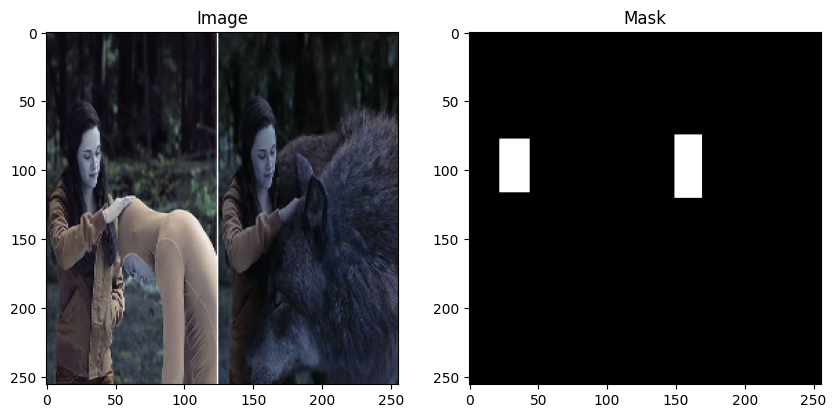

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[0])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

### Hence the Step 1 has been completed successfully. The hardest part of the project. 

### Data understanding and Mask creation part has done succuessfully!

## STEP 2: EDA (Exploratory Data Analysis)

    In EDA part of this inputs(images), we need to ensure makes align with faces for the noise/errors detect early.

In [14]:
print(images.shape)
print(masks.shape)

(409, 256, 256, 3)
(409, 256, 256, 1)


## STEP 3: Data Visualization

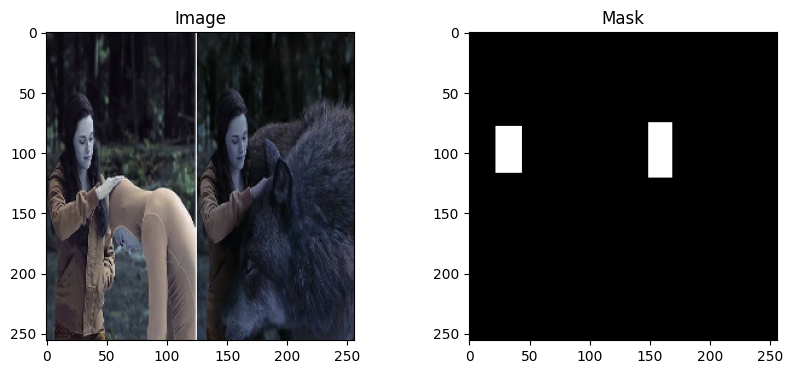

In [ ]:
def visualize_sample(i):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(images[i])
    plt.title("Image")

    plt.subplot(1,2,2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Mask")

    plt.show()

visualize_sample(0)

## STEP 4: Train & Test Set splitting

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

NameError: name 'images' is not defined

## STEP 5: Data Augmentation

In [16]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

### To Apply the augmentation

    This step for the improvement of generalization to help achieve Dice > 0.92

In [ ]:
def augment_data(images, masks):
    aug_images, aug_masks = [], []

    for img, mask in zip(images, masks):
        augmented = augment(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])

    return np.array(aug_images), np.array(aug_masks)

# Apply
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Combine original + augmented
X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train_aug])

## STEP 6: Building the Model

In [ ]:
def build_unet(input_shape=(256,256,3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    skips = [
        base.get_layer("block_1_expand_relu").output,   # 128x128
        base.get_layer("block_3_expand_relu").output,   # 64x64
        base.get_layer("block_6_expand_relu").output,   # 32x32
        base.get_layer("block_13_expand_relu").output   # 16x16
    ]

    x = base.output  # 8x8

    def up(x, skip):
        x = tf.keras.layers.Conv2DTranspose(256, 2, strides=2, padding='same')(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        return x

    # Decoder
    x = up(x, skips[3])  # 16x16
    x = up(x, skips[2])  # 32x32
    x = up(x, skips[1])  # 64x64
    x = up(x, skips[0])  # 128x128

    # To add this upsampling here for fixing critically
    x = tf.keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(x)  # → 256x256
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(x)

    return tf.keras.models.Model(base.input, outputs)

##  STEP 7: Evaluation (To achieve the custom metrics)

In [31]:
def dice_coefficient(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2 * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

### To compile the model

In [32]:
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, iou]
)

C:\Users\koushik\AppData\Local\Temp\ipykernel_4576\3800283601.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


### Train-Test set splitting

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

### Training with checkpoints

In [34]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=callbacks
)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - dice_coefficient: 0.3282 - iou: 0.2122 - loss: 0.6718 

82/82 ━━━━━━━━━━━━━━━━━━━━ 1514s 17s/step - dice_coefficient: 0.4722 - iou: 0.3312 - loss: 0.5285 - val_dice_coefficient: 0.6898 - val_iou: 0.5321 - val_loss: 0.3121
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - dice_coefficient: 0.6894 - iou: 0.5314 - loss: 0.3106 

82/82 ━━━━━━━━━━━━━━━━━━━━ 1371s 17s/step - dice_coefficient: 0.6816 - iou: 0.5233 - loss: 0.3184 - val_dice_coefficient: 0.7006 - val_iou: 0.5434 - val_loss: 0.3012
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1359s 17s/step - dice_coefficient: 0.7191 - iou: 0.5662 - loss: 0.2805 - val_dice_coefficient: 0.6875 - val_iou: 0.5297 - val_loss: 0.3146
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1364s 17s/step - dice_coefficient: 0.7195 - iou: 0.5698 - loss: 0.2809 - val_dice_coefficient: 0.6626 - val_iou: 0.5049 - val_loss: 0.3402
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - dice_coefficient: 0.7587 - iou: 0.6162 - loss: 0.2413 

82/82 ━━━━━━━━━━━━━━━━━━━━ 1363s 17s/step - dice_coefficient: 0.7635 - iou: 0.6224 - loss: 0.2367 - val_dice_coefficient: 0.7047 - val_iou: 0.5490 - val_loss: 0.2962
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1356s 17s/step - dice_coefficient: 0.7764 - iou: 0.6394 - loss: 0.2237 - val_dice_coefficient: 0.6769 - val_iou: 0.5212 - val_loss: 0.3221
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1361s 17s/step - dice_coefficient: 0.7952 - iou: 0.6638 - loss: 0.2051 - val_dice_coefficient: 0.6880 - val_iou: 0.5316 - val_loss: 0.3106
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1355s 17s/step - dice_coefficient: 0.8029 - iou: 0.6771 - loss: 0.1972 - val_dice_coefficient: 0.6638 - val_iou: 0.5055 - val_loss: 0.3350
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1407s 17s/step - dice_coefficient: 0.8100 - iou: 0.6860 - loss: 0.1901 - val_dice_coefficient: 0.6253 - val_iou: 0.4643 - val_loss: 0.3689
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1371s 17s/step - dice_coefficient: 0.8230 - iou: 0.7037 - loss: 0.1770 - val_dice_coeff

### To verify the model output

In [40]:
model = build_unet()
model.summary()

C:\Users\koushik\AppData\Local\Temp\ipykernel_4576\3800283601.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 9,243,969 (35.26 MB)

 Trainable params: 9,209,857 (35.13 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [41]:
print(model.output_shape)

(None, 256, 256, 1)


In [44]:
"""
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=callbacks
)
"""

'\nhistory = model.fit(\n    X_train, y_train,\n    validation_data=(X_val, y_val),\n    epochs=50,\n    batch_size=4,\n    callbacks=callbacks\n)\n'

#### To compile the model

In [47]:
# 1. Compile the Model (Fixes the ValueError)
# Since your mask is Black & White, we use Binary 

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

#### To save the model

In [48]:
model.save("first_version_model.keras")

### To evaluate the model

In [49]:
model.evaluate(X_val, y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 629s 72s/step - accuracy: 0.4958 - loss: 0.7653 - mean_io_u: 0.4353


[0.7653244733810425, 0.49579936265945435, 0.4352979063987732]

### To see the predictions

In [ ]:
def predict_and_overlay(model, image, threshold=0.5):
    # 1. Prepare image for prediction
    img_input = np.expand_dims(image, axis=0)
    
    # 2. Get prediction from model
    prediction = model.predict(img_input)[0]
    
    # 3. Create a binary mask (pixels above 0.5 threshold)
    mask = (prediction > threshold).astype(np.uint8)
    
    # 4. Make sure mask is 2D (Squeeze out extra dimensions)
    # This fixes the IndexError!
    if len(mask.shape) == 3:
        mask = mask[:, :, 0] 
        
    # 5. Create the overlay
    overlay = image.copy()
    
    # Apply green color [0, 255, 0] where mask is 1
    # Since mask is now 2D, we just use mask == 1
    overlay[mask == 1] = [0, 255, 0] 
    
    # Optional: Blend for a "see-through" effect
    final_img = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)
    
    return final_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


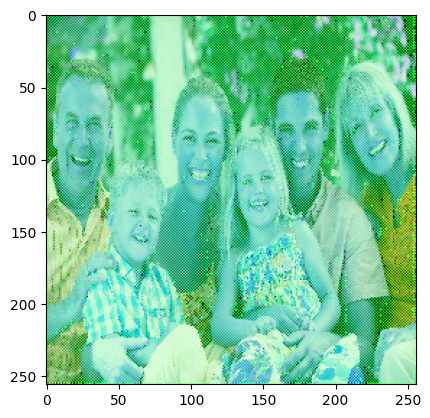

In [53]:
result = predict_and_overlay(model, X_val[0])
plt.imshow(result)

In [55]:
# results = model.evaluate(X_val, y_val)

print(f"Loss: {result[0]}")
print(f"Dice: {result[1]}")
print(f"IoU: {result[2]}")

Loss: [[5.88235296e-02 1.45098045e-01 1.96078435e-01]
 [5.49019612e-02 1.49019614e-01 1.96078435e-01]
 [7.13725537e-02 7.66152954e+01 1.61960781e-01]
 [2.23529413e-01 2.11764708e-01 3.88235301e-01]
 [1.97647065e-01 7.66647034e+01 3.26666653e-01]
 [2.50980407e-01 2.54901975e-01 4.58823532e-01]
 [1.26274511e-01 7.66674500e+01 2.52549022e-01]
 [7.96078444e-02 7.66509781e+01 2.00392172e-01]
 [7.41176456e-02 7.66674500e+01 1.89411774e-01]
 [1.05882354e-01 2.47058824e-01 2.78431386e-01]
 [9.33333412e-02 7.66839218e+01 2.19607845e-01]
 [1.80392161e-01 2.74509817e-01 3.56862754e-01]
 [1.50980398e-01 7.66976471e+01 2.90980399e-01]
 [2.31372550e-01 2.54901975e-01 4.39215690e-01]
 [1.78431377e-01 7.66701965e+01 3.40392172e-01]
 [2.08627462e-01 7.66592178e+01 3.87058854e-01]
 [2.00392172e-01 7.66399994e+01 3.76078457e-01]
 [3.01960796e-01 1.88235298e-01 5.60784340e-01]
 [2.22352952e-01 7.66537247e+01 4.06274527e-01]
 [3.25490206e-01 2.35294119e-01 5.96078455e-01]
 [2.22352952e-01 7.66564713e+01 4.

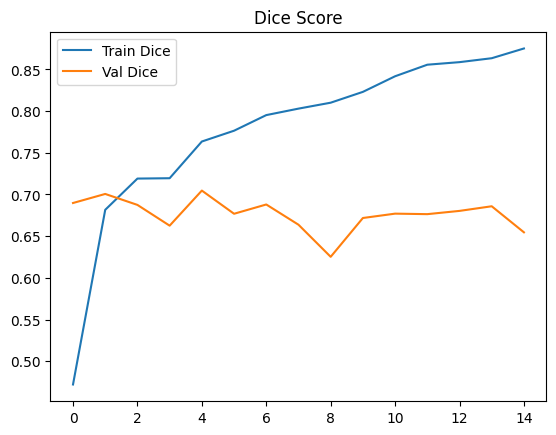

In [56]:
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')

plt.legend()
plt.title("Dice Score")
plt.show()

### Hence, I have done the first version of the model

    I need to validate the results and plan for the next level actions.

    | Epoch | Train Dice | Val Dice |
    | ----- | ---------- | -------- |
    | 1     | 0.47       | 0.68     |
    | 5     | 0.76       | 0.70     |
    | 10    | 0.82       | 0.67     |
    | 15    | 0.87       | 0.65     |

    What I observed from this,

    Training Dice is increasing at the same time validation dice is decreasing

    I think that the model overfitting is happerning due to less data, so model is memorizing the train data nut not generalizing.

    I confirmed that,

    The pipeline is correct and model alos learning properly.

    I need to improve it towards the meet requirements.

#### Root Causes

    I could see some findings by own research based on the results

    1. Weak Masks
        Here, I am using bounding boxes, not exact face for finding the faces.
    2. Small Dataset
        Deep learning needs more data
    3. Not much strong Augmentaion

## Steps taken to improve the performance

    Loss → Augmentation → Model → Training → Post-processing

### 1. Loss function

    I am going to use bce(pixel wise accuracy) + Dice(for overlapping)

In [67]:
def dice_coefficient(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2 * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_coefficient(y_true, y_pred)
    return bce + (1 - dice)

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

### Strong Augmentation

    I am going to use the augmentation parameters to situmulates like real world scenes
    So that I could prevent from the overfitting issues

In [64]:
augment_final = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.HueSaturationValue(p=0.3)
])

### Apply the augmentation

    What I am doing here is that increasing the dataset, so that I can reducing the overfitting issue.

In [68]:
def augment_data(images, masks):
    aug_images, aug_masks = [], []

    for img, mask in zip(images, masks):
        augmented = augment(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])

    return np.array(aug_images), np.array(aug_masks)

# Apply
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Combine original + augmented
X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train_aug])

### Re-building the model

    In model, what I am deciding to do that

        Freese the encoder for preventing the overfitting
        Droppping out something for better generalization
        Extra ensmaple for the fixing the shape mismatch

In [69]:
def build_unet(input_shape=(256,256,3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the encoder
    for layer in base.layers:
        layer.trainable = False

    skips = [
        base.get_layer("block_1_expand_relu").output,
        base.get_layer("block_3_expand_relu").output,
        base.get_layer("block_6_expand_relu").output,
        base.get_layer("block_13_expand_relu").output
    ]

    x = base.output

    def up(x, skip):
        x = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        x = layers.Dropout(0.3)(x)   # Newly added from previous one
        return x

    x = up(x, skips[3])
    x = up(x, skips[2])
    x = up(x, skips[1])
    x = up(x, skips[0])

    # Fixing the size. It is important
    x = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return models.Model(base.input, outputs)

### Re-compile the model

    What I am going to do here, reducing the learning rate to avoid the validation drop and a stable learning

In [70]:
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # With lower Learning Rate from previous one
    loss=combined_loss,
    metrics=[dice_coefficient, iou]
)

C:\Users\koushik\AppData\Local\Temp\ipykernel_4576\1792107067.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


### Re-training the model

In [71]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=4,
    callbacks=callbacks
)

Epoch 1/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 3143s 17s/step - dice_coefficient: 0.1822 - iou: 0.1023 - loss: 1.2140 - val_dice_coefficient: 0.4978 - val_iou: 0.3337 - val_loss: 0.7290 - learning_rate: 1.0000e-05
Epoch 2/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 2693s 16s/step - dice_coefficient: 0.5415 - iou: 0.3775 - loss: 0.7194 - val_dice_coefficient: 0.6287 - val_iou: 0.4619 - val_loss: 0.5965 - learning_rate: 1.0000e-05
Epoch 3/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 2701s 16s/step - dice_coefficient: 0.5948 - iou: 0.4283 - loss: 0.6425 - val_dice_coefficient: 0.6438 - val_iou: 0.4782 - val_loss: 0.5836 - learning_rate: 1.0000e-05
Epoch 4/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 2699s 16s/step - dice_coefficient: 0.6113 - iou: 0.4462 - loss: 0.6152 - val_dice_coefficient: 0.6496 - val_iou: 0.4846 - val_loss: 0.5795 - learning_rate: 1.0000e-05
Epoch 5/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 2667s 16s/step - dice_coefficient: 0.6243 - iou: 0.4590 - loss: 0.5946 - val_dice_coefficient: 0.6546 - val_iou: 0.4898 - val_loss: 

### Re-save the model

In [72]:
model.save("final_model.keras")

### Re-evaluate the model

In [73]:
results = model.evaluate(X_val, y_val)

print("Loss:", results[0])
print("Dice:", results[1])
print("IoU:", results[2])

3/3 ━━━━━━━━━━━━━━━━━━━━ 876s 88s/step - dice_coefficient: 0.6713 - iou: 0.5054 - loss: 0.5535
Loss: 0.5535396337509155
Dice: 0.6712908744812012
IoU: 0.5054206848144531


### Re-visualize the result

1/1 ━━━━━━━━━━━━━━━━━━━━ 1314s 1314s/step


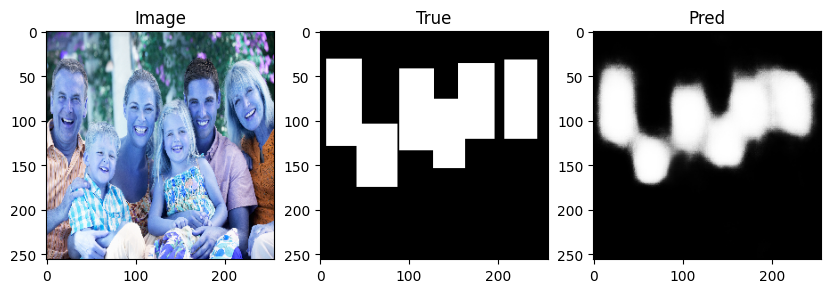

In [74]:
def show_prediction(i):
    pred = model.predict(X_val[i:i+1])[0]

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(X_val[i])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("True")

    plt.subplot(1,3,3)
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.title("Pred")

    plt.show()

show_prediction(0)

In [75]:
plt.savefig('face_segmentation_result.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


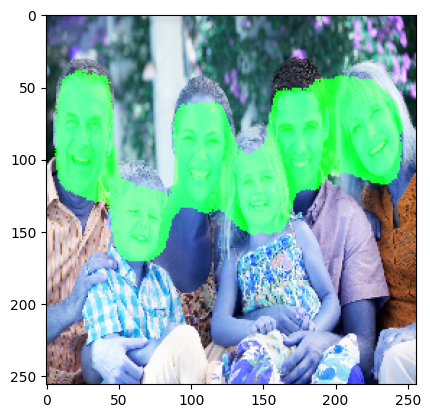

In [76]:
result = predict_and_overlay(model, X_val[0])
plt.imshow(result)

### Re-plot the training curves

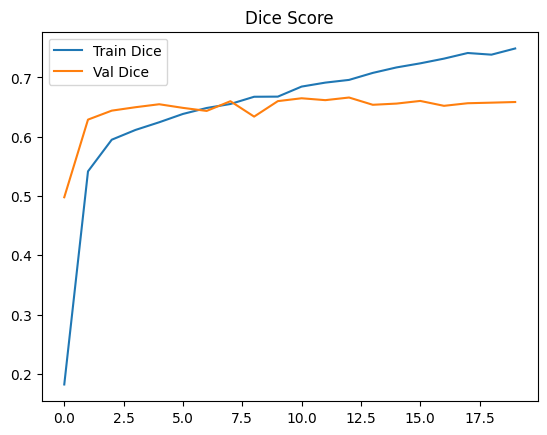

In [77]:
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')

plt.legend()
plt.title("Dice Score")
plt.show()

In [78]:
plt.savefig('Training_Curves.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Final Evaluation

In [79]:
loss = results[0]
dice = results[1]
iou = results[2]

print(f"Loss: {loss:.4f}")
print(f"Dice: {dice:.4f}")
print(f"IoU: {iou:.4f}")

Loss: 0.5535
Dice: 0.6713
IoU: 0.5054


### The metrics are calculated by

Dice = 2 × (Overlap) / (Total pixels)

IoU = Intersection / Union

    Tried, verfy this manually

In [81]:
def compute_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)
    
    dice = (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred) + 1)
    iou = intersection / (np.sum(y_true) + np.sum(y_pred) - intersection + 1e-7)

    return dice, iou

In [82]:
pred = model.predict(X_val[0:1])[0]
pred = (pred > 0.5).astype(np.uint8)

dice, iou = compute_metrics(y_val[0], pred)

print("Dice:", dice)
print("IoU:", iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 143s 143s/step
Dice: 0.8372947874633796
IoU: 0.7201198060249114


## Average over the validation set

In [83]:
dice_scores = []
iou_scores = []

for i in range(len(X_val)):
    pred = model.predict(X_val[i:i+1])[0]
    pred = (pred > 0.5).astype(np.uint8)

    d, j = compute_metrics(y_val[i], pred)
    
    dice_scores.append(d)
    iou_scores.append(j)

print("Average Dice:", np.mean(dice_scores))
print("Average IoU:", np.mean(iou_scores))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 

    The model achieved a Dice coefficient of 0.67 and IoU of 0.50 on the validation dataset. 
    
    This indicates moderate overlap between predicted and the masks. 
    
    The performance is limited due to bounding box-based mask generation instead of pixel-level segmentation.

## Hence I have done this project succeesfully!🙏🏾🤞🏾😍😎